<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/CASO_ARBOLES_DE_CLASIFICACION_RANDOM_FOREST_Y_REGRESION_LOGISTICAS_PARA_DATOS_DE_SALUD_ARBOLES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

Este caso de estudio es similar al visto con programación *R*. Se trata de implementar evaluar y comparar modelos de clasificación con información relacionada con el estado de salud de una muestra simulada de características de árboles. El caso que se presenta se construye con funcipnes de bibliotecas y funciones de *Python*.

Son 15 las variables independientes:

Las de tipo dandométricas o mediciones físicas de los árboles: *edad*, es edad estimada del árbol, unidad en años;
*altura*, es la altura total del árbol medida en metros; *diametro*, es el diámetro del tronco medido a la altura del pecho centímetros; *area*, es la superficie ocupada por la copa metros cuadrados; *densidad*, es la densidad relativa del follaje medido en porcentaje.

Variables relativas a las condiciones del suelo edáficas: *ph*, la acidez o alcalinidad del suelo; *humedad* es el  porcentaje de contenido de humedad del suelo (%); *materia_organica*, es el porcentaje de materia orgánica; *nitrogeno*, es la concentración de nitrógeno; *fosforo* es la concentración de fósforo.

Variables relativas a las condiciones del clima: *temperatura*, la temperatura promedio; *precipitacion* la cantidad de precipitación acumulada; *radiacion* el indicador de radiación solar promedio; *viento* la velocidad promedio del viento.

Variable de tipo topográfica: *altitud* que es la altitud sobre el nivel del mar.

La variable dependiente es la de *salud* que define la condición de sanidad de un árbol y puede tener valores de *Enfermedad*, *Estres_Hidrico*, *Plaga* o *Sano*.

Los datos ya vienen transformados, limpios y con clases balanceadas para garantizar certidumbre en la construcción de modelos.

Los datos para su descarga se encuentran en el enlace de github.com en el espacio del autor: https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_forestal_multinomial.csv .

Las funciones previamente codificadas y preparadas para este caso de estudio se pueden encontrar en *github.com* en PENDIENTE .

El caso de estudio se encuentra en el portal de *google collab* https://colab.research.google.com/drive/1gjJs0H3AuQDDshFi5JGvADpCBFLTPrbJ?usp=sharing .

De igual manera el caso de estudio puede encontrarse en el portal de *github.com* en https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/CASO_ARBOLES_DE_CLASIFICACION_RANDOM_FOREST_Y_REGRESION_LOGISTICAS_PARA_DATOS_DE_SALUD_ARBOLES.ipynb .




# Objetivo

Crear, evaluar y comparar modelos de clasificación con datos relacionados con el estado de salud de árboles. Los modelos que se crean son árboles de clasificación, bosques aleatorios y regresión logística.

Se partición los datos *70%* para datos de entrenamiento y *30%* para datos de validación.

La evaluación de los modelos se hace a través de los estadísticos extraídos a partir de la matriz de confusión de cada modelo.

Al final se interpreta el caso de estudio mencionando el modelo con mayor calidad predictiva para estos datos.


# Descripción

Se cargan librerías, funciones que permiten la adecuada ejecución del caso de estudio; se cargan los datos, se visualizan y describen identificando los estadísticos de las variables independientes y la frecuencia de clase de la variable dependiente *salud*.

## Cargar librerías



In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import LassoCV
# from sklearn.linear_model import RidgeCV
# from sklearn.metrics import ( mean_squared_error,
#    mean_absolute_error,  r2_score )

# from scipy.stats import shapiro
# from scipy.stats import kstest
# from statsmodels.stats.diagnostic import het_breuschpagan
# from statsmodels.stats.stattools import durbin_watson
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.stats.diagnostic import linear_reset
# import statsmodels.api as sm

# Para validar posutalados
# from statsmodels.stats.outliers_influence import (
#    variance_inflation_factor)
# from statsmodels.stats.diagnostic import (het_breuschpagan,
#    linear_reset)
# from statsmodels.stats.stattools import ( durbin_watson)
# from scipy.stats import ( shapiro)
# from scipy.stats import shapiro
# from scipy.stats import kstest
# from scipy.stats import anderson
# from sklearn.linear_model import (  LassoCV)
# from sklearn.linear_model import (  RidgeCV)
# from sklearn.preprocessing import (PolynomialFeatures)
# from sklearn.svm import SVR # Para modelos SVR

# Para arboles de clasificación y bosques aleatorios
from sklearn.tree import DecisionTreeClassifier # Árbol de clasificación
from sklearn.ensemble import RandomForestClassifier # Bosque aleatorio de clasificación
from sklearn.tree import plot_tree # Visualización del árbol
from sklearn.tree import export_text # Exportar reglas del árbol

from sklearn.linear_model import LogisticRegression # Reg Logistica
from sklearn.utils import resample # Muestras y submuestras


## Cargar funciones


In [61]:
# Funciones para implementar y evaluar modelos árboles y bosques aleatorios
# como modelos de clasifgicación

# Permite cosntruir modelos de regresión logística Python
# Se valida el postulado de colinealidad NO LO SE AUN....
#
# Rubén Pizarro Gurrola
# Junio 2026

#========================================================
# CARGAR DATOS
#========================================================

def f_cargar_datos(ruta_archivo):

    datos = pd.read_csv(ruta_archivo)

    return datos

#========================================================
# VISUALIZAR HEAD Y TAIL
#========================================================

def f_visualizar_head_tail_reducido(
        datos,
        n = 6
):

    #----------------------------------------------------
    # Total columnas
    #----------------------------------------------------

    total_columnas = datos.shape[1]

    #----------------------------------------------------
    # Primeras 4 columnas
    #----------------------------------------------------

    idx_prim = list(
        range(
            min(4, total_columnas)
        )
    )

    #----------------------------------------------------
    # Últimas 4 columnas
    #----------------------------------------------------

    idx_ult = list(
        range(
            max(total_columnas - 4, 0),
            total_columnas
        )
    )

    #----------------------------------------------------
    # Evitar duplicados
    #----------------------------------------------------

    idx_ult = [
        i for i in idx_ult
        if i not in idx_prim
    ]

    #----------------------------------------------------
    # Subconjuntos
    #----------------------------------------------------

    datos_prim = datos.iloc[:, idx_prim]

    datos_ult = datos.iloc[:, idx_ult]

    #----------------------------------------------------
    # HEAD
    #----------------------------------------------------

    head_prim = (
        datos_prim
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    head_ult = (
        datos_ult
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # TAIL
    #----------------------------------------------------

    tail_prim = (
        datos_prim
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    tail_ult = (
        datos_ult
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # Separadores
    #----------------------------------------------------

    sep_head = pd.DataFrame({
        "...": ["..."] * n
    })

    sep_tail = pd.DataFrame({
        "...": ["..."] * n
    })

    #----------------------------------------------------
    # Combinar HEAD
    #----------------------------------------------------

    head_comb = pd.concat(

        [
            head_prim,
            sep_head,
            head_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Combinar TAIL
    #----------------------------------------------------

    tail_comb = pd.concat(

        [
            tail_prim,
            sep_tail,
            tail_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Fila separadora
    #----------------------------------------------------

    fila_sep = pd.DataFrame(

        [["..."] * head_comb.shape[1]],

        columns = head_comb.columns
    )

    #----------------------------------------------------
    # Tabla final
    #----------------------------------------------------

    tabla = pd.concat(

        [
            head_comb,
            fila_sep,
            tail_comb
        ],

        ignore_index = True
    )

    return tabla

#========================================================
# DESCRIBIR DATOS
#========================================================

#========================================================
# FUNCIÓN
# f_describir_datos()
#========================================================

def f_describir_datos(datos):

    import pandas as pd

    #----------------------------------------------------
    # ESTRUCTURA
    #----------------------------------------------------

    estructura = datos.dtypes

    #----------------------------------------------------
    # VARIABLES NUMÉRICAS
    #----------------------------------------------------

    variables_numericas = datos.select_dtypes(
        include=["number"]
    )

    describe_numericas = None

    if variables_numericas.shape[1] > 0:

        describe_numericas = (
            variables_numericas
            .describe()
            .T
            .round(4)
        )

    #----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #----------------------------------------------------

    variables_categoricas = datos.select_dtypes(
        include=["object", "category"]
    )

    frecuencias = {}

    for variable in variables_categoricas.columns:

        tabla = pd.DataFrame({

            "Frecuencia":
                datos[variable]
                .value_counts(),

            "Porcentaje":
                round(
                    datos[variable]
                    .value_counts(normalize=True)
                    * 100,
                    2
                )

        })

        frecuencias[variable] = tabla

    #----------------------------------------------------
    # RESULTADO
    #----------------------------------------------------

    return {
        "describe": describe_numericas,
        "frecuencias": frecuencias,
        "structure": estructura
    }

#=========================================================
# FUNCIÓN
# f_frecuencias_clases()
#=========================================================

def f_frecuencias_clases(
        datos,
        ncols = 1,
        figsize = (18, 12),
        hspace = 0.60,
        wspace = 0.30):

    """
    Genera diagramas de barras para todas las variables
    categóricas (object, category y bool).

    Argumentos:
    ------------------------------------------------------
    datos    : DataFrame
    ncols    : Número de columnas del grid
    figsize  : Tamaño de la figura
    hspace   : Espacio vertical entre filas
    wspace   : Espacio horizontal entre columnas
    """

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    #-----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #-----------------------------------------------------

    variables = datos.select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    ).columns.tolist()

    if len(variables) == 0:

        print(
            "No existen variables categóricas en el conjunto de datos."
        )

        return

    #-----------------------------------------------------
    # GRID
    #-----------------------------------------------------

    nvars = len(variables)

    nrows = int(
        np.ceil(
            nvars / ncols
        )
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize = figsize
    )

    #-----------------------------------------------------
    # ASEGURAR VECTOR DE EJES
    #-----------------------------------------------------

    if nvars == 1:

        axes = np.array([axes])

    else:

        axes = np.array(axes).reshape(-1)

    #-----------------------------------------------------
    # GRÁFICOS
    #-----------------------------------------------------

    for i, variable in enumerate(variables):

        frecuencias = (
            datos[variable]
            .value_counts(dropna = False)
        )

        frecuencias.plot(
            kind = "bar",
            ax = axes[i]
        )

        #-------------------------------------------------
        # TÍTULO
        #-------------------------------------------------

        axes[i].set_title(
            variable,
            fontsize = 11,
            pad = 12
        )

        axes[i].set_xlabel("")

        axes[i].set_ylabel(
            "Frecuencia"
        )

        #-------------------------------------------------
        # ROTACIÓN ETIQUETAS
        #-------------------------------------------------

        axes[i].tick_params(
            axis = "x",
            rotation = 45,
            labelsize = 8
        )

        #-------------------------------------------------
        # ETIQUETAS SOBRE BARRAS
        #-------------------------------------------------

        for barra in axes[i].patches:

            altura = barra.get_height()

            axes[i].annotate(

                f"{int(altura):,}",

                (
                    barra.get_x() +
                    barra.get_width()/2,
                    altura
                ),

                ha = "center",

                va = "bottom",

                fontsize = 8

            )

    #-----------------------------------------------------
    # ELIMINAR EJES SOBRANTES
    #-----------------------------------------------------

    for j in range(
        len(variables),
        len(axes)
    ):

        fig.delaxes(
            axes[j]
        )

    #-----------------------------------------------------
    # ESPACIADO
    #-----------------------------------------------------

    plt.subplots_adjust(

        hspace = hspace,

        wspace = wspace

    )

    plt.tight_layout(
        pad = 2.5
    )

    plt.show()


def f_estandarizar_escalar(datos,
                           decimales = 4):

    datos_est = datos.copy()
    datos_esc = datos.copy()

    columnas_num = datos.select_dtypes(include = np.number).columns

    scaler_est = StandardScaler()

    scaler_minmax = MinMaxScaler()

    datos_est[columnas_num] = np.round(
        scaler_est.fit_transform(datos[columnas_num]),
        decimales
    )

    datos_esc[columnas_num] = np.round(
        scaler_minmax.fit_transform(datos[columnas_num]),
        decimales
    )

    return {
        "datos_estandarizados": datos_est,
        "datos_escalados": datos_esc
    }


#=========================================================
# FUNCIÓN
# f_convertir_dummys()
#=========================================================

def f_convertir_dummys(datos):

    """
    Convierte automáticamente todas las variables
    categóricas (object, category y bool)
    en variables dummy.

    Argumentos
    ----------
    datos : DataFrame

    Retorna
    -------
    DataFrame con variables dummy
    """

    import pandas as pd

    #-----------------------------------------------------
    # COPIA
    #-----------------------------------------------------

    datos_dummys = datos.copy()

    #-----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #-----------------------------------------------------

    variables_categoricas = (
        datos_dummys
        .select_dtypes(
            include=[
                "object",
                "category",
                "bool"
            ]
        )
        .columns
    )

    #-----------------------------------------------------
    # DUMMIES
    #-----------------------------------------------------

    datos_dummys = pd.get_dummies(

        datos_dummys,

        columns = variables_categoricas,

        drop_first = True,

        dtype = int

    )

    #-----------------------------------------------------
    # INFORMACIÓN
    #-----------------------------------------------------

    print()

    print("="*40)

    print(" CONVERSIÓN A VARIABLES DUMMY ")

    print("="*40)

    print(
        "Variables originales :",
        datos.shape[1]
    )

    print(
        "Variables finales    :",
        datos_dummys.shape[1]
    )

    print(
        "Observaciones        :",
        datos_dummys.shape[0]
    )

    print("="*40)

    return datos_dummys

def f_particionar_datos(datos,
                         proporcion_entrenamiento = 0.7):

    datos_entrenamiento, datos_validacion = train_test_split(
        datos,
        train_size = proporcion_entrenamiento,
        random_state = 2026
    )

    return {
        "datos_entrenamiento": datos_entrenamiento,
        "datos_validacion": datos_validacion
    }

#=========================================================
# FUNCIÓN
# f_construir_arbol_clasificacion()
#=========================================================

def f_construir_arbol_clasificacion(
        datos,
        variable_dependiente,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=123):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd

    from sklearn.tree import DecisionTreeClassifier

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if variable_dependiente not in datos.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe."
        )

    #-----------------------------------------------------
    # X e y
    #-----------------------------------------------------

    X = datos.drop(
        columns=[variable_dependiente]
    )

    y = datos[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # MODELO
    #-----------------------------------------------------

    modelo = DecisionTreeClassifier(

        criterion=criterion,

        max_depth=max_depth,

        min_samples_split=min_samples_split,

        min_samples_leaf=min_samples_leaf,

        random_state=random_state
    )

    modelo.fit(X, y)

    #-----------------------------------------------------
    # METADATOS
    #-----------------------------------------------------

    modelo.variable_dependiente = variable_dependiente

    modelo.n_clases = y.nunique()

    modelo.clases = list(y.unique())

    modelo.frecuencias_clases = (
        y.value_counts()
        .sort_index()
        .to_dict()
    )

    modelo.n_variables = X.shape[1]

    #-----------------------------------------------------
    # RESUMEN
    #-----------------------------------------------------

    print()
    print("====================================")
    print(" ÁRBOL DE CLASIFICACIÓN")
    print("====================================")
    print("Variable objetivo :", variable_dependiente)
    print("Número clases     :", modelo.n_clases)
    print("Variables         :", modelo.n_variables)
    print("Criterio          :", criterion)
    print("Observaciones     :", len(datos))
    print()

    print("Frecuencia de clases")

    for k, v in modelo.frecuencias_clases.items():

        print(f"{k}: {v}")

    print("====================================")

    return modelo


#=========================================================
# FUNCIÓN
# f_visualizar_arbol()
#=========================================================

def f_visualizar_arbol(
        modelo,
        figsize=(22,12),
        profunidad=3,
        fontsize=9):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import matplotlib.pyplot as plt

    from sklearn.tree import plot_tree

    from sklearn.tree import DecisionTreeClassifier

    #-----------------------------------------------------
    # VALIDACIÓN
    #-----------------------------------------------------

    if not isinstance(
        modelo,
        DecisionTreeClassifier
    ):

        raise ValueError(
            "El modelo debe ser DecisionTreeClassifier."
        )

    #-----------------------------------------------------
    # FIGURA
    #-----------------------------------------------------

    plt.figure(
        figsize=figsize
    )

    plot_tree(

        modelo,

        filled=True,

        rounded=True,

        feature_names=modelo.feature_names_in_,

        class_names=[
            str(x)
            for x in modelo.classes_
        ],

        max_depth=profunidad,

        fontsize=fontsize
    )

    plt.title(
        "Árbol de Clasificación"
    )

    plt.show()


#=========================================================
# FUNCIÓN
# f_variables_importantes()
#=========================================================

def f_variables_importantes(
        modelos,
        nombres_modelos=None,
        top=10,
        ncols=2,
        figsize=(14,8)):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd

    import matplotlib.pyplot as plt

    import math

    #-----------------------------------------------------
    # CONVERTIR A LISTA
    #-----------------------------------------------------

    if not isinstance(modelos, list):

        modelos = [modelos]

    #-----------------------------------------------------
    # NOMBRES
    #-----------------------------------------------------

    if nombres_modelos is None:

        nombres_modelos = [
            f"Modelo {i+1}"
            for i in range(len(modelos))
        ]

    #-----------------------------------------------------
    # GRID
    #-----------------------------------------------------

    n_modelos = len(modelos)

    nrows = math.ceil(
        n_modelos / ncols
    )

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize
    )

    #-----------------------------------------------------
    # AJUSTAR AXES
    #-----------------------------------------------------

    if n_modelos == 1:

        axes = [axes]

    else:

        axes = axes.flatten()

    #-----------------------------------------------------
    # TABLA GLOBAL
    #-----------------------------------------------------

    tabla_global = []

    #-----------------------------------------------------
    # RECORRER MODELOS
    #-----------------------------------------------------

    for i, modelo in enumerate(modelos):

        importancia = pd.DataFrame({

            "Variable":
                modelo.feature_names_in_,

            "Importancia":
                modelo.feature_importances_

        })

        importancia = (

            importancia

            .sort_values(
                by="Importancia",
                ascending=False
            )

            .head(top)

            .reset_index(drop=True)

        )

        importancia["Modelo"] = (
            nombres_modelos[i]
        )

        tabla_global.append(
            importancia
        )

        #-------------------------------------------------
        # GRÁFICA
        #-------------------------------------------------

        ax = axes[i]

        ax.barh(

            importancia["Variable"],

            importancia["Importancia"]

        )

        ax.invert_yaxis()

        ax.set_title(
            nombres_modelos[i]
        )

        ax.set_xlabel(
            "Importancia"
        )

        ax.set_ylabel("")

    #-----------------------------------------------------
    # ELIMINAR EJES VACÍOS
    #-----------------------------------------------------

    for j in range(
        n_modelos,
        len(axes)
    ):

        fig.delaxes(
            axes[j]
        )

    #-----------------------------------------------------
    # AJUSTES
    #-----------------------------------------------------

    plt.tight_layout()

    plt.show()

    #-----------------------------------------------------
    # TABLA CONSOLIDADA
    #-----------------------------------------------------

    tabla_global = pd.concat(
        tabla_global,
        ignore_index=True
    )

    return tabla_global


#=========================================================
# FUNCIÓN
# f_construir_random_forest()
#=========================================================

def f_construir_random_forest(
        datos,
        variable_dependiente,
        n_estimators=500,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=123):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd

    from sklearn.ensemble import RandomForestClassifier

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if variable_dependiente not in datos.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe."
        )

    #-----------------------------------------------------
    # X e y
    #-----------------------------------------------------

    X = datos.drop(
        columns=[variable_dependiente]
    )

    y = datos[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # MODELO
    #-----------------------------------------------------

    modelo = RandomForestClassifier(

        n_estimators=n_estimators,

        criterion=criterion,

        max_depth=max_depth,

        min_samples_split=min_samples_split,

        min_samples_leaf=min_samples_leaf,

        max_features=max_features,

        random_state=random_state,

        n_jobs=-1
    )

    modelo.fit(X, y)

    #-----------------------------------------------------
    # METADATOS
    #-----------------------------------------------------

    modelo.variable_dependiente = (
        variable_dependiente
    )

    modelo.n_clases = y.nunique()

    modelo.clases = list(
        y.unique()
    )

    modelo.frecuencias_clases = (
        y.value_counts()
         .sort_index()
         .to_dict()
    )

    modelo.n_variables = X.shape[1]

    #-----------------------------------------------------
    # RESUMEN
    #-----------------------------------------------------

    print()
    print("==================================================")
    print(" RANDOM FOREST")
    print("==================================================")

    print(
        f"Variable objetivo : {variable_dependiente}"
    )

    print(
        f"Número de clases  : {modelo.n_clases}"
    )

    print(
        f"Variables         : {modelo.n_variables}"
    )

    print(
        f"Árboles           : {n_estimators}"
    )

    print(
        f"Criterio          : {criterion}"
    )

    print(
        f"Observaciones     : {len(datos)}"
    )

    print()
    print("Frecuencias:")

    for clase, frecuencia in (
        modelo.frecuencias_clases.items()
    ):

        print(
            f"{clase}: {frecuencia}"
        )

    print("==================================================")

    return modelo

#=========================================================
# FUNCIÓN
# f_estandarizar_train_transf_valid()
#=========================================================

def f_estandarizar_train_transf_valid(
        datos_entrenamiento,
        datos_validacion,
        variable_dependiente):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd

    from sklearn.preprocessing import StandardScaler

    #-----------------------------------------------------
    # COPIAS
    #-----------------------------------------------------

    entrenamiento = datos_entrenamiento.copy()

    validacion = datos_validacion.copy()

    #-----------------------------------------------------
    # X TRAIN
    #-----------------------------------------------------

    X_train = entrenamiento.drop(
        columns=[variable_dependiente]
    )

    y_train = entrenamiento[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # X VALID
    #-----------------------------------------------------

    X_valid = validacion.drop(
        columns=[variable_dependiente]
    )

    y_valid = validacion[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # ESCALADOR
    #-----------------------------------------------------

    scaler = StandardScaler()

    #-----------------------------------------------------
    # AJUSTAR SOLO TRAIN
    #-----------------------------------------------------

    X_train_std = scaler.fit_transform(
        X_train
    )

    #-----------------------------------------------------
    # TRANSFORMAR VALIDACIÓN
    #-----------------------------------------------------

    X_valid_std = scaler.transform(
        X_valid
    )

    #-----------------------------------------------------
    # DATAFRAMES
    #-----------------------------------------------------

    X_train_std = pd.DataFrame(
        X_train_std,
        columns=X_train.columns,
        index=X_train.index
    )

    X_valid_std = pd.DataFrame(
        X_valid_std,
        columns=X_valid.columns,
        index=X_valid.index
    )

    #-----------------------------------------------------
    # RECONSTRUIR DATASETS
    #-----------------------------------------------------

    datos_entrenamiento_std = pd.concat(
        [X_train_std, y_train],
        axis=1
    )

    datos_validacion_std = pd.concat(
        [X_valid_std, y_valid],
        axis=1
    )

    #-----------------------------------------------------
    # RESULTADO
    #-----------------------------------------------------

    return {

        "datos_entrenamiento":
            datos_entrenamiento_std,

        "datos_validacion":
            datos_validacion_std,

        "scaler":
            scaler

    }

#=========================================================
# FUNCIÓN
# f_crear_modelo_regresion_logistica()
#=========================================================

def f_crear_modelo_regresion_logistica(
        datos,
        variable_dependiente,
        tipo="binomial",
        balanceo="ninguno",
        semilla=123):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd
    import numpy as np

    from sklearn.linear_model import LogisticRegression

    from sklearn.utils import resample

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if variable_dependiente not in datos.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe."
        )

    #-----------------------------------------------------
    # COPIA
    #-----------------------------------------------------

    np.random.seed(semilla)

    datos = datos.copy()

    datos_originales = datos.copy()

    #-----------------------------------------------------
    # VARIABLE DEPENDIENTE
    #-----------------------------------------------------

    y = datos[variable_dependiente]

    X = datos.drop(
        columns=[variable_dependiente]
    )

    #-----------------------------------------------------
    # FRECUENCIAS ORIGINALES
    #-----------------------------------------------------

    frecuencias_originales = (
        y
        .value_counts()
        .to_dict()
    )

    porcentajes_originales = (
        y
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    #-----------------------------------------------------
    # NÚMERO DE CLASES
    #-----------------------------------------------------

    n_clases = y.nunique()

    #-----------------------------------------------------
    # PONDERACIONES
    #-----------------------------------------------------

    class_weight = None

    #-----------------------------------------------------
    # BALANCEO
    #-----------------------------------------------------

    if balanceo.lower() == "undersampling":

        frecuencia_min = y.value_counts().min()

        datos_balanceados = []

        for clase in y.unique():

            temp = datos[
                datos[variable_dependiente] == clase
            ]

            temp = resample(
                temp,
                replace=False,
                n_samples=frecuencia_min,
                random_state=semilla
            )

            datos_balanceados.append(temp)

        datos = pd.concat(
            datos_balanceados,
            axis=0
        )

        datos = datos.sample(
            frac=1,
            random_state=semilla
        )

        y = datos[variable_dependiente]

        X = datos.drop(
            columns=[variable_dependiente]
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "oversampling":

        frecuencia_max = y.value_counts().max()

        datos_balanceados = []

        for clase in y.unique():

            temp = datos[
                datos[variable_dependiente] == clase
            ]

            temp = resample(
                temp,
                replace=True,
                n_samples=frecuencia_max,
                random_state=semilla
            )

            datos_balanceados.append(temp)

        datos = pd.concat(
            datos_balanceados,
            axis=0
        )

        datos = datos.sample(
            frac=1,
            random_state=semilla
        )

        y = datos[variable_dependiente]

        X = datos.drop(
            columns=[variable_dependiente]
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "smote":

        from imblearn.over_sampling import SMOTE

        smote = SMOTE(
            random_state=semilla
        )

        X, y = smote.fit_resample(
            X,
            y
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "ponderacion":

        class_weight = "balanced"

    #-----------------------------------------------------

    elif balanceo.lower() == "ninguno":

        pass

    #-----------------------------------------------------

    else:

        raise ValueError(
            "balanceo debe ser: "
            "'ninguno', "
            "'undersampling', "
            "'oversampling', "
            "'SMOTE' o "
            "'ponderacion'"
        )

    #-----------------------------------------------------
    # FRECUENCIAS ENTRENAMIENTO
    #-----------------------------------------------------

    frecuencias_entrenamiento = (
        pd.Series(y)
        .value_counts()
        .to_dict()
    )

    porcentajes_entrenamiento = (
        pd.Series(y)
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    #-----------------------------------------------------
    # MODELO BINOMIAL
    #-----------------------------------------------------

    if tipo.lower() == "binomial":

        if n_clases != 2:

            raise ValueError(
                "La regresión logística binomial "
                "requiere exactamente 2 clases."
            )

        modelo = LogisticRegression(

            class_weight=class_weight,

            max_iter=5000,

            random_state=semilla

        )

    #-----------------------------------------------------
    # MODELO MULTINOMIAL
    #-----------------------------------------------------

    elif tipo.lower() == "multinomial":

        modelo = LogisticRegression(

            # multi_class="multinomial",

            solver="lbfgs",

            class_weight=class_weight,

            max_iter=3000,

            random_state=semilla

        )

    #-----------------------------------------------------

    else:

        raise ValueError(
            "tipo debe ser "
            "'binomial' o "
            "'multinomial'"
        )

    #-----------------------------------------------------
    # AJUSTE
    #-----------------------------------------------------

    modelo.fit(X, y)

    #-----------------------------------------------------
    # METADATOS
    #-----------------------------------------------------

    modelo.variable_dependiente = variable_dependiente

    modelo.tipo_modelo = tipo

    modelo.balanceo = balanceo

    modelo.n_clases = n_clases

    modelo.frecuencias_originales = frecuencias_originales

    modelo.porcentajes_originales = porcentajes_originales

    modelo.frecuencias_entrenamiento = frecuencias_entrenamiento

    modelo.porcentajes_entrenamiento = porcentajes_entrenamiento

    #-----------------------------------------------------
    # RESUMEN
    #-----------------------------------------------------

    print()

    print("="*50)

    print(" REGRESIÓN LOGÍSTICA ")

    print("="*50)

    print("Tipo               :", tipo)

    print("Balanceo           :", balanceo)

    print("Variable objetivo  :", variable_dependiente)

    print("Número de clases   :", n_clases)

    print()

    print("Frecuencias originales:")

    print(frecuencias_originales)

    print()

    print("Frecuencias entrenamiento:")

    print(frecuencias_entrenamiento)

    print()

    print("Observaciones usadas:", len(y))

    print("="*50)

    return modelo

#=========================================================
# FUNCIÓN
# f_predicciones()
#=========================================================

def f_predicciones(
        modelo,
        datos_validacion,
        variable_dependiente):

    import pandas as pd
    import numpy as np

    #-----------------------------------------------------
    # VARIABLES INDEPENDIENTES
    #-----------------------------------------------------

    X = datos_validacion.drop(
        columns=[variable_dependiente]
    )

    #-----------------------------------------------------
    # CLASES PREDICHAS
    #-----------------------------------------------------

    pred = modelo.predict(X)

    #-----------------------------------------------------
    # PROBABILIDADES
    #-----------------------------------------------------

    prob = modelo.predict_proba(X)

    #-----------------------------------------------------
    # BINOMIAL
    #-----------------------------------------------------

    if len(modelo.classes_) == 2:

        probabilidad = prob[:,1]

    #-----------------------------------------------------
    # MULTINOMIAL
    #-----------------------------------------------------

    else:

        probabilidad = np.max(
            prob,
            axis=1
        )

    #-----------------------------------------------------
    # RESULTADO
    #-----------------------------------------------------

    resultado = pd.DataFrame({

        "Real":
            datos_validacion[
                variable_dependiente
            ].values,

        "Prediccion":
            pred,

        "Probabilidad":
            np.round(
                probabilidad,
                4
            )

    })

    resultado["Porcentual"] = (

        resultado["Probabilidad"] * 100

    ).round(2).astype(str) + " %"

    return resultado

#=========================================================
# FUNCIÓN
# f_matriz_confusion()
#=========================================================

def f_matriz_confusion(
        modelo,
        datos_validacion,
        variable_dependiente,
        clase_interes=None):

    import pandas as pd

    from sklearn.metrics import (
        confusion_matrix,
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        balanced_accuracy_score,
        cohen_kappa_score
    )

    #-----------------------------------------------------
    # DATOS
    #-----------------------------------------------------

    X = datos_validacion.drop(
        columns=[variable_dependiente]
    )

    y_real = datos_validacion[
        variable_dependiente
    ]

    y_pred = modelo.predict(X)

    #-----------------------------------------------------
    # MATRIZ
    #-----------------------------------------------------

    matriz = confusion_matrix(
        y_real,
        y_pred
    )

    tabla_mc = pd.DataFrame(

        matriz,

        index=[
            f"Real_{x}"
            for x in modelo.classes_
        ],

        columns=[
            f"Pred_{x}"
            for x in modelo.classes_
        ]

    )

    #-----------------------------------------------------
    # MÉTRICAS
    #-----------------------------------------------------

    accuracy = accuracy_score(
        y_real,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_real,
        y_pred
    )

    #-----------------------------------------------------
    # BINOMIAL
    #-----------------------------------------------------

    if len(modelo.classes_) == 2:

        if clase_interes is None:

            clase_interes = modelo.classes_[1]

        precision = precision_score(

            y_real,

            y_pred,

            pos_label=clase_interes

        )

        recall = recall_score(

            y_real,

            y_pred,

            pos_label=clase_interes

        )

        f1 = f1_score(

            y_real,

            y_pred,

            pos_label=clase_interes

        )

        balanced_accuracy = (

            balanced_accuracy_score(

                y_real,

                y_pred

            )

        )

    #-----------------------------------------------------
    # MULTINOMIAL
    #-----------------------------------------------------

    else:

        precision = precision_score(

            y_real,

            y_pred,

            average="weighted"

        )

        recall = recall_score(

            y_real,

            y_pred,

            average="weighted"

        )

        f1 = f1_score(

            y_real,

            y_pred,

            average="weighted"

        )

        balanced_accuracy = (

            balanced_accuracy_score(

                y_real,

                y_pred

            )

        )

    #-----------------------------------------------------
    # RESULTADOS
    #-----------------------------------------------------

    estadisticos = pd.DataFrame({

        "Accuracy":
            [round(accuracy,4)],

        "Kappa":
            [round(kappa,4)],

        "Precision":
            [round(precision,4)],

        "Recall":
            [round(recall,4)],

        "F1":
            [round(f1,4)],

        "Balanced_Accuracy":
            [round(
                balanced_accuracy,
                4
            )]

    })

    return {

        "matriz_confusion":
            tabla_mc,

        "estadisticos":
            estadisticos

    }

#=========================================================
# FUNCIÓN
# f_evaluacion()
#=========================================================

def f_evaluacion(
        modelos,
        datos_validacion,
        variable_dependiente,
        clase_interes=None,
        nombres_modelos=None):

    import pandas as pd

    #-----------------------------------------------------
    # CONVERTIR MODELO A LISTA
    #-----------------------------------------------------

    if not isinstance(modelos, list):

        modelos = [modelos]

    #-----------------------------------------------------
    # DATOS VALIDACIÓN
    #-----------------------------------------------------

    if not isinstance(datos_validacion, list):

        datos_validacion = (
            [datos_validacion]
            * len(modelos)
        )

    #-----------------------------------------------------
    # NOMBRES
    #-----------------------------------------------------

    if nombres_modelos is None:

        nombres_modelos = [

            f"Modelo {i+1}"

            for i in range(
                len(modelos)
            )

        ]

    #-----------------------------------------------------
    # RESULTADOS
    #-----------------------------------------------------

    resultados = []

    #-----------------------------------------------------
    # RECORRER MODELOS
    #-----------------------------------------------------

    for i in range(len(modelos)):

        modelo = modelos[i]

        datos_val = datos_validacion[i]

        nombre = nombres_modelos[i]

        #---------------------------------------------
        # MATRIZ DE CONFUSIÓN
        #---------------------------------------------

        resultado_mc = (

            f_matriz_confusion(

                modelo=modelo,

                datos_validacion=datos_val,

                variable_dependiente=
                    variable_dependiente,

                clase_interes=
                    clase_interes

            )

        )

        est = (
            resultado_mc[
                "estadisticos"
            ]
            .copy()
        )

        est.insert(
            0,
            "Modelo",
            nombre
        )

        #---------------------------------------------
        # BALANCEO
        #---------------------------------------------

        if hasattr(
            modelo,
            "balanceo"
        ):

            est.insert(

                1,

                "Balanceo",

                modelo.balanceo

            )

        resultados.append(est)

    #-----------------------------------------------------
    # UNIR
    #-----------------------------------------------------

    resultados = pd.concat(

        resultados,

        ignore_index=True

    )

    return resultados

## Cargar datos

Se cargan los datos con la función *f_cargar_datos (url)* ya utilizada en otros casos de estudio.

In [62]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_forestal_multinomial.csv"
datos = f_cargar_datos (url)

## Visualizar datos

Con la función *f_visualizar_head_tail_reducido(datos)*, se presentan los primeros y últimos registros del conjunto de datos al igual que las primeras y últimas cuatro variables, siendo la última columna la variable dependiente.

In [63]:
f_visualizar_head_tail_reducido(datos)

,edad,altura,diametro,area,...,radiacion,viento,altitud,salud
0,38,12.94,29.57,40.96,...,7.31,13.0,931.45,Estres_Hidrico
1,19,9.06,43.47,55.68,...,7.96,13.32,1271.1,Estres_Hidrico
2,19,9.74,27.23,52.15,...,7.72,11.39,1199.06,Sano
3,35,10.86,39.23,43.66,...,8.95,13.2,1462.42,Plaga
4,8,22.06,42.01,57.25,...,8.59,10.72,1041.67,Sano
5,22,8.38,24.53,36.47,...,5.35,12.02,1238.07,Enfermedad
6,...,...,...,...,...,...,...,...,...
7,16,12.94,46.27,52.94,...,6.23,10.24,1210.76,Sano
8,30,18.96,37.49,41.54,...,8.22,13.82,974.52,Estres_Hidrico
9,30,13.32,26.63,53.89,...,10.18,13.5,1321.05,Estres_Hidrico


## Estadísticos descriptivos

Se presentan los estadísticos descriptivos de las variables numéricas que son todas las independientes, la frecuencia de clases de la variable categórica dependiente llamada *salud* y la estructura de los datos.


In [64]:
estadisticos = f_describir_datos(datos) # ["describe"]
# estadisticos
estadisticos["describe"]


,count,mean,std,min,25%,50%,75%,max
edad,1000.0,24.1530,9.2043,8.00,16.0000,25.000,32.0000,39.00
altura,1000.0,13.5346,3.1944,3.65,11.3725,13.480,15.6550,23.34
diametro,1000.0,31.5806,6.6596,6.77,27.7150,31.530,35.8225,57.81
area,1000.0,45.0808,10.3088,13.62,37.9450,44.755,52.0225,80.98
densidad,1000.0,57.2967,16.4581,16.18,45.4100,55.220,69.7375,108.88
ph,1000.0,6.4143,0.5262,4.58,6.0700,6.495,6.7800,7.61
humedad,1000.0,39.7078,17.4613,5.74,24.3875,40.115,52.0100,83.37
materia_organica,1000.0,4.5796,1.2548,0.47,3.7075,4.560,5.4400,8.27
nitrogeno,1000.0,27.2752,7.2631,8.74,22.1150,27.170,32.2100,47.53
fosforo,1000.0,19.5636,5.4721,2.09,15.4450,19.470,23.5125,34.89


In [65]:
print(estadisticos["frecuencias"])

{'salud':                 Frecuencia  Porcentaje
salud                                 
Estres_Hidrico         250        25.0
Sano                   250        25.0
Plaga                  250        25.0
Enfermedad             250        25.0}


In [66]:
print(estadisticos["structure"])

edad                  int64
altura              float64
diametro            float64
area                float64
densidad            float64
ph                  float64
humedad             float64
materia_organica    float64
nitrogeno           float64
fosforo             float64
temperatura         float64
precipitacion       float64
radiacion           float64
viento              float64
altitud             float64
salud                object
dtype: object


## Frecuencia de clase

Se visualiza el diagrama de barra que indica la frecuencia de clases de la variable dependiente llamada *salud*.

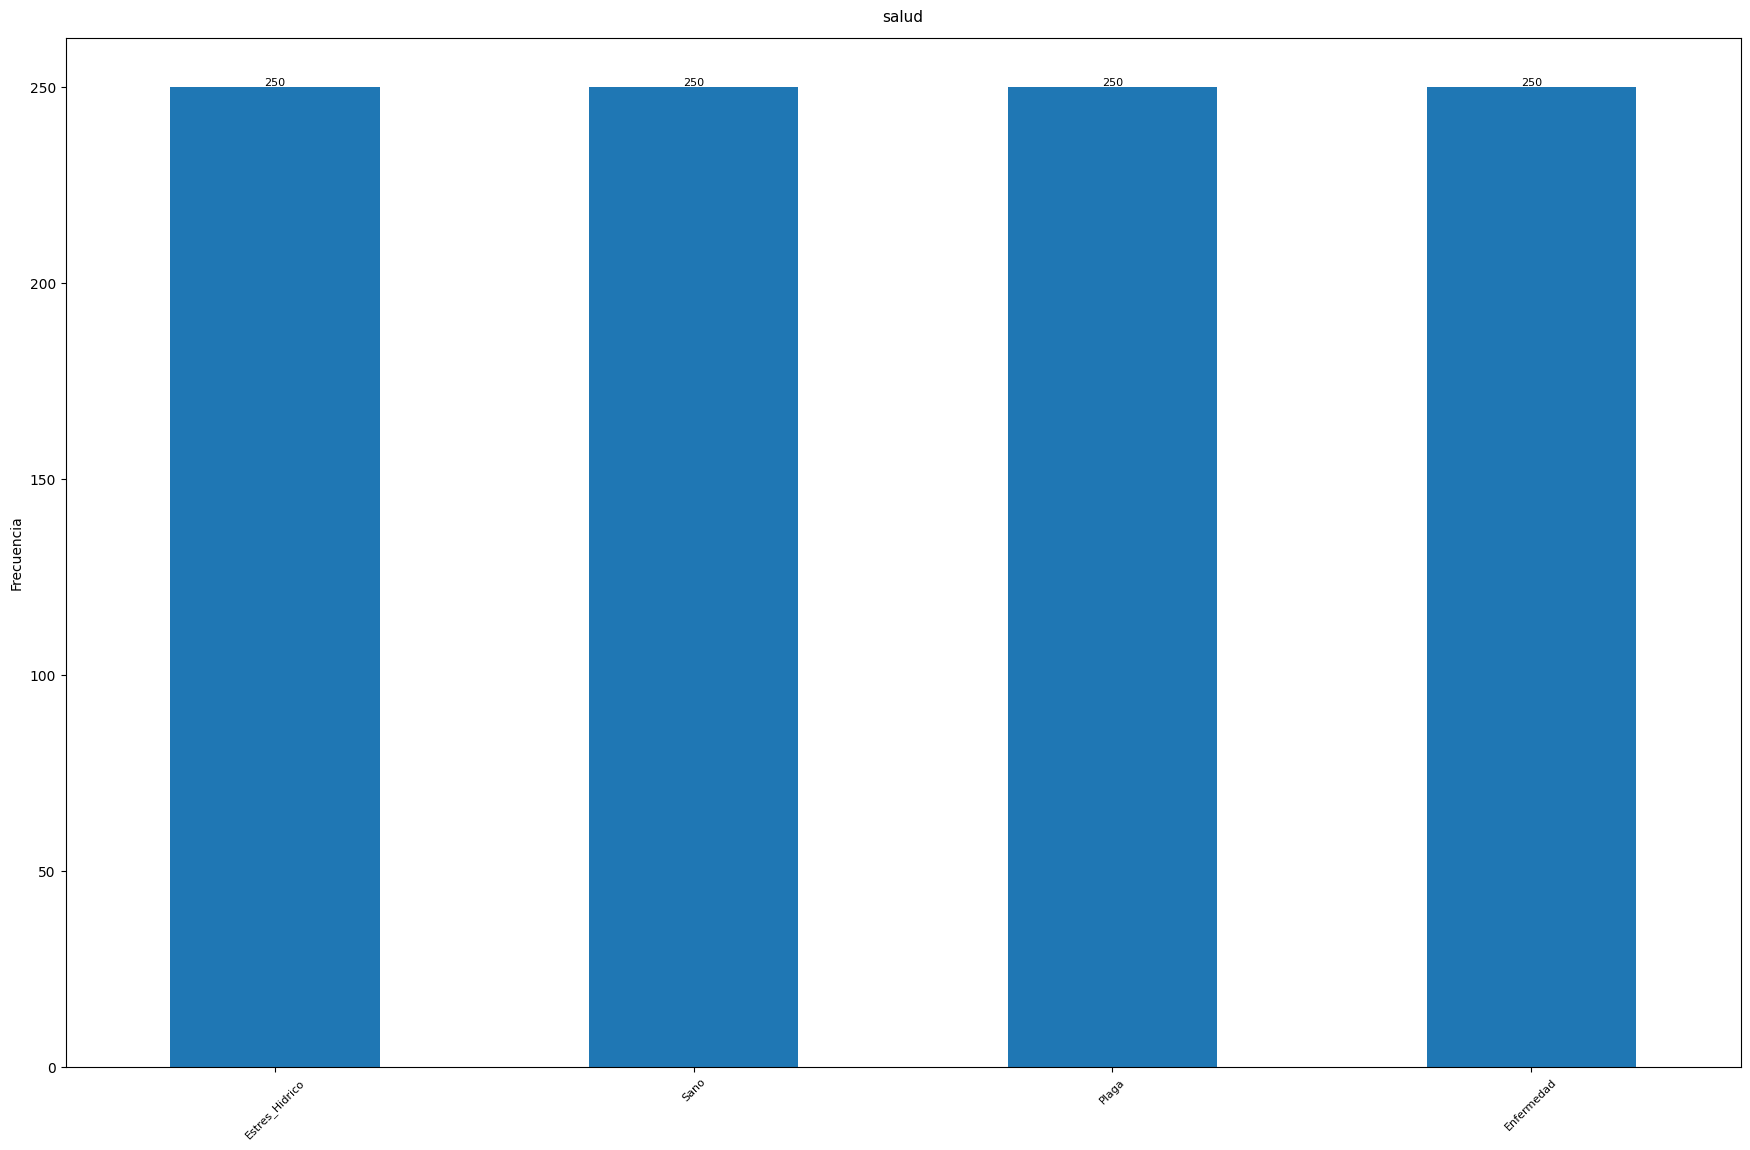

In [67]:
f_frecuencias_clases(datos)

# Desarrollo


## Datos de entrenamiento y datos de validación

Con la función *f_particionar_datos()* se crean los conjuntos datos de entrenamiento con el *70%* y el *30%* para datos validación respectivamente.

Datos de entrenamiento:


In [68]:
particiones = f_particionar_datos(datos)
datos_entrenamiento = particiones["datos_entrenamiento"]
datos_validacion = particiones["datos_validacion"]
f_visualizar_head_tail_reducido(datos_entrenamiento)

,edad,altura,diametro,area,...,radiacion,viento,altitud,salud
0,34,9.28,30.8,46.93,...,5.34,12.47,1343.42,Enfermedad
1,34,13.32,24.23,39.14,...,7.86,13.67,1072.2,Plaga
2,25,17.55,32.43,34.59,...,9.0,11.48,925.19,Plaga
3,28,17.07,31.07,40.25,...,8.04,10.13,1472.71,Plaga
4,11,11.15,32.9,43.84,...,8.15,12.13,961.36,Estres_Hidrico
5,8,19.73,22.31,49.98,...,6.93,11.38,1282.96,Enfermedad
6,...,...,...,...,...,...,...,...,...
7,36,15.56,36.67,55.72,...,5.63,10.65,976.2,Sano
8,29,10.56,35.35,42.74,...,9.53,12.82,1322.76,Estres_Hidrico
9,8,13.96,20.83,37.78,...,7.53,14.86,1352.75,Enfermedad


In [69]:
f_visualizar_head_tail_reducido(datos_validacion)

,edad,altura,diametro,area,...,radiacion,viento,altitud,salud
0,11,14.46,30.32,52.1,...,6.31,9.33,1175.47,Sano
1,13,10.58,29.61,53.5,...,4.86,14.89,1303.56,Enfermedad
2,10,14.28,36.68,41.7,...,6.48,12.58,972.38,Plaga
3,36,7.42,17.43,34.72,...,7.35,12.51,1083.24,Enfermedad
4,12,14.46,33.18,45.38,...,6.6,10.75,1098.03,Plaga
5,15,11.02,26.25,33.64,...,6.27,12.68,1065.9,Enfermedad
6,...,...,...,...,...,...,...,...,...
7,32,19.46,35.9,43.65,...,6.0,11.84,1073.06,Plaga
8,29,13.58,28.48,42.55,...,6.9,10.52,837.06,Enfermedad
9,34,15.65,29.87,44.23,...,7.28,15.2,1011.15,Plaga


## Modelo árbol de clasificación

Se crean dos árboles de clasificación con los mismos datos de entrenamiento, solo que el primero de ellos en su argumento lleva la etiqueta del tipo de árbol basado en criterio de medidas de impurezas *Gini* y el segundo con entropía.

El resultado de ambos árboles es muy similar en cuanto a las reglas de decisión, lo que hace pensar que la estructura de los datos permite identificar patrones estables independientemente del criterio de impureza usado.

### Arbol de clasificación con medida de impureza Gini

Este modelo se llama *modelo_AC_entropia*


In [70]:
modelo_AC_gini = f_construir_arbol_clasificacion(
    datos_entrenamiento,
    "salud",
    criterion="gini"
)


 ÁRBOL DE CLASIFICACIÓN
Variable objetivo : salud
Número clases     : 4
Variables         : 15
Criterio          : gini
Observaciones     : 700

Frecuencia de clases
Enfermedad: 178
Estres_Hidrico: 177
Plaga: 175
Sano: 170


### Visualizar árbol con criterio de impureza Gini

Para visualizar el árbol, se ejecuta la función *f_visualizar_arbol*.

Con cuatro niveles de profunidad en el árbol se observan que las variables importantes que definen las principales reglas de decisión para clasificar estados de salud de los árboles son *humedad*, *precipitación*, *densidad*, *temperatura*, esto tiene sentido porque son aspectos agronómicos y forestale que define la salud de plantas, en este caso árboles.

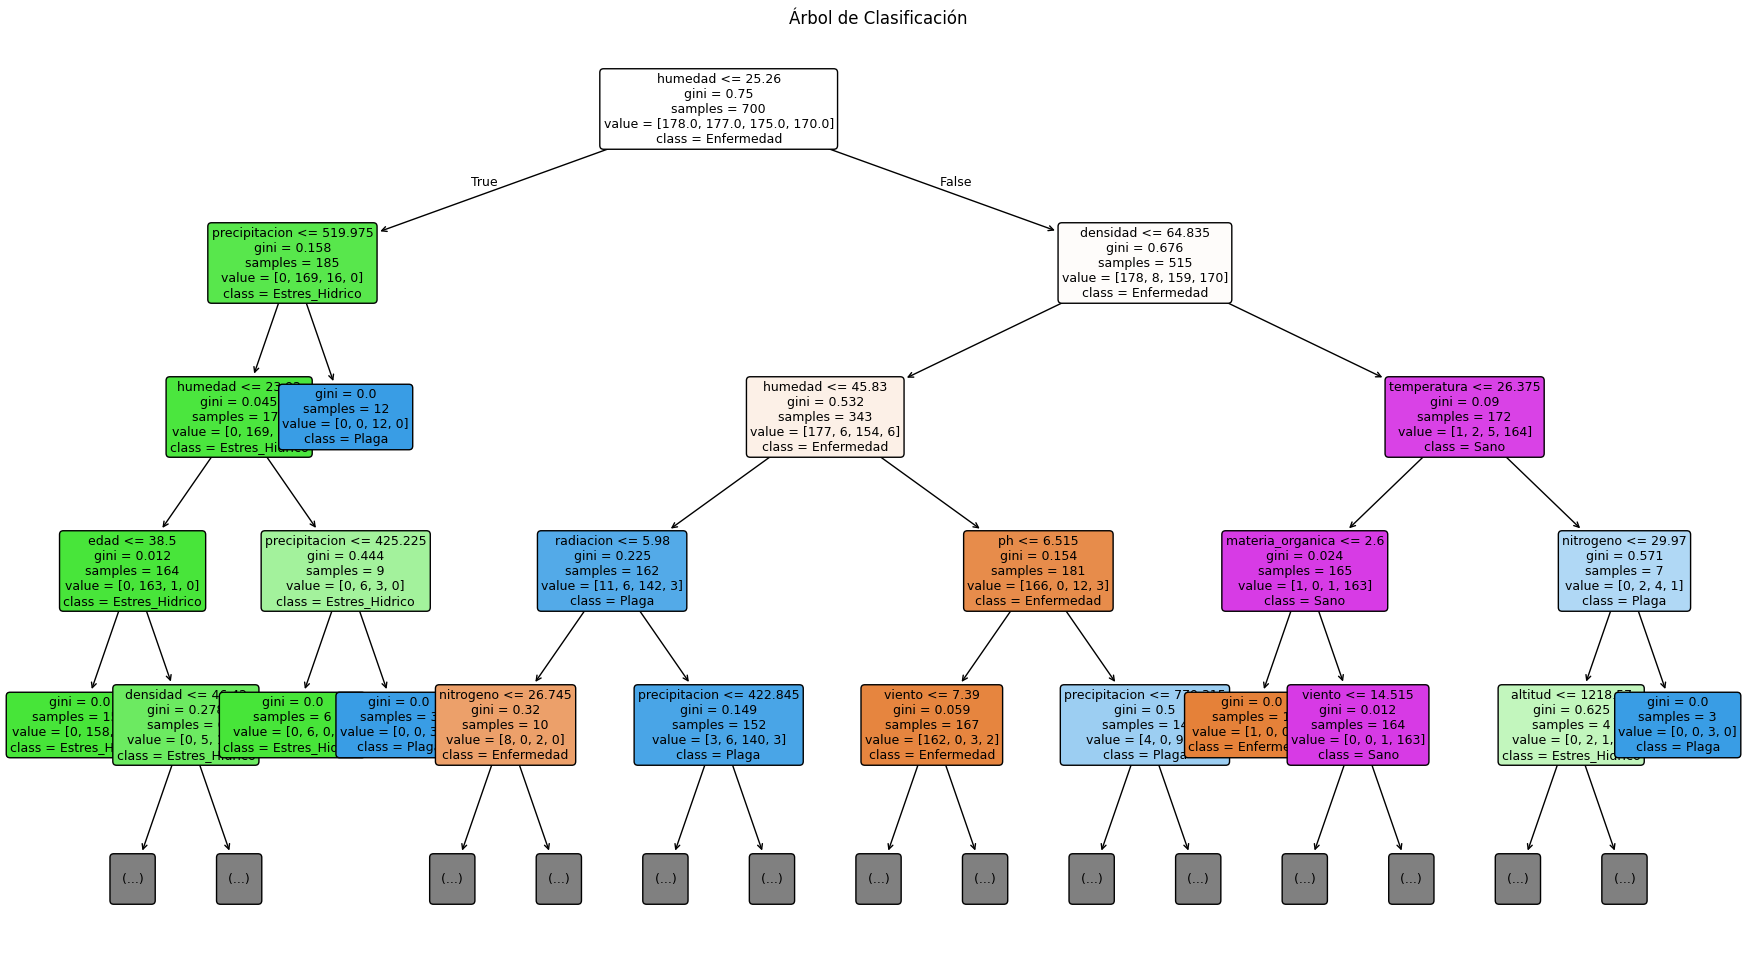

In [71]:
f_visualizar_arbol(modelo_AC_gini, profunidad=4)

### Arbol de clasificación con medida de impureza entropía

Este modelo se llama *modelo_AC_entropia*.

In [72]:
modelo_AC_entropia = f_construir_arbol_clasificacion(
    datos_entrenamiento,
    "salud",
    criterion="entropy"
)


 ÁRBOL DE CLASIFICACIÓN
Variable objetivo : salud
Número clases     : 4
Variables         : 15
Criterio          : entropy
Observaciones     : 700

Frecuencia de clases
Enfermedad: 178
Estres_Hidrico: 177
Plaga: 175
Sano: 170


### Visualizar árbol con criterio de impureza entropía

Para visualizar el árbol con criterio entropía, se ejecuta de igual manera la función *f_visualizar_arbol*.

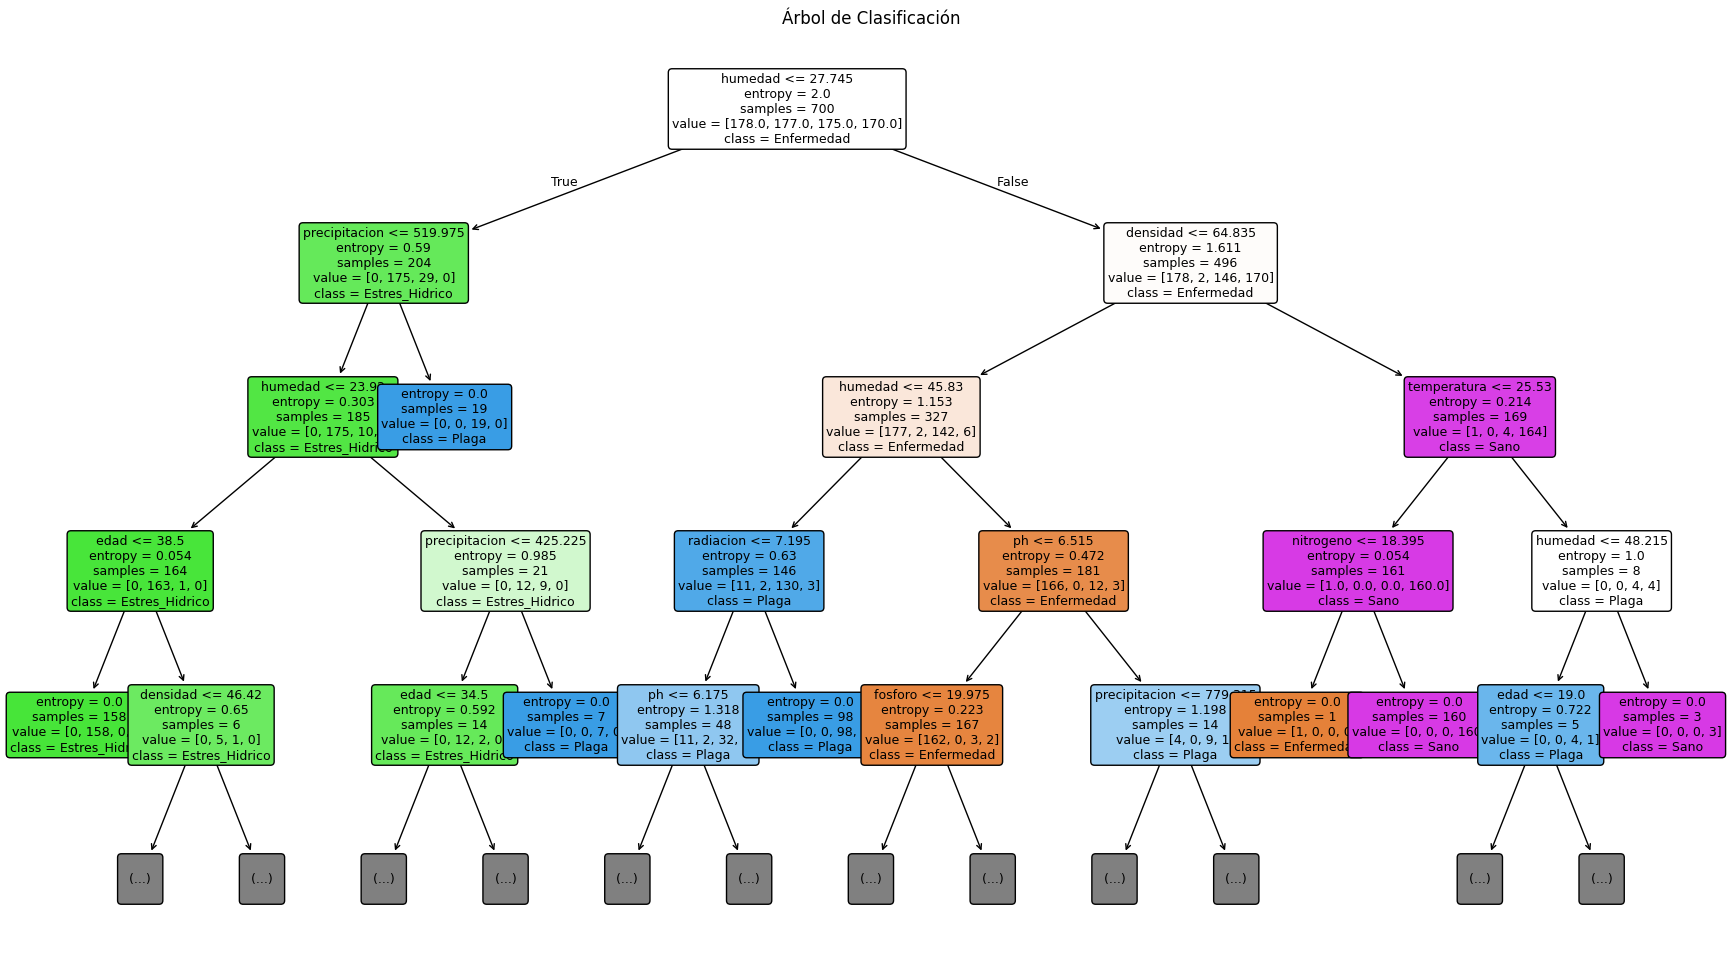

In [73]:
f_visualizar_arbol(modelo_AC_entropia, profunidad=4)

## Variables importantes

Al ejecutar la función *f_variables_importantes()* se muestran las variables importantes en ambos modelos. Los resultados arrojan que en ambos modelos, las variables de *humedad*, *densidad* y *precipitación* representan aproximadamente *87%* de la importancia de la salud de un árbol.

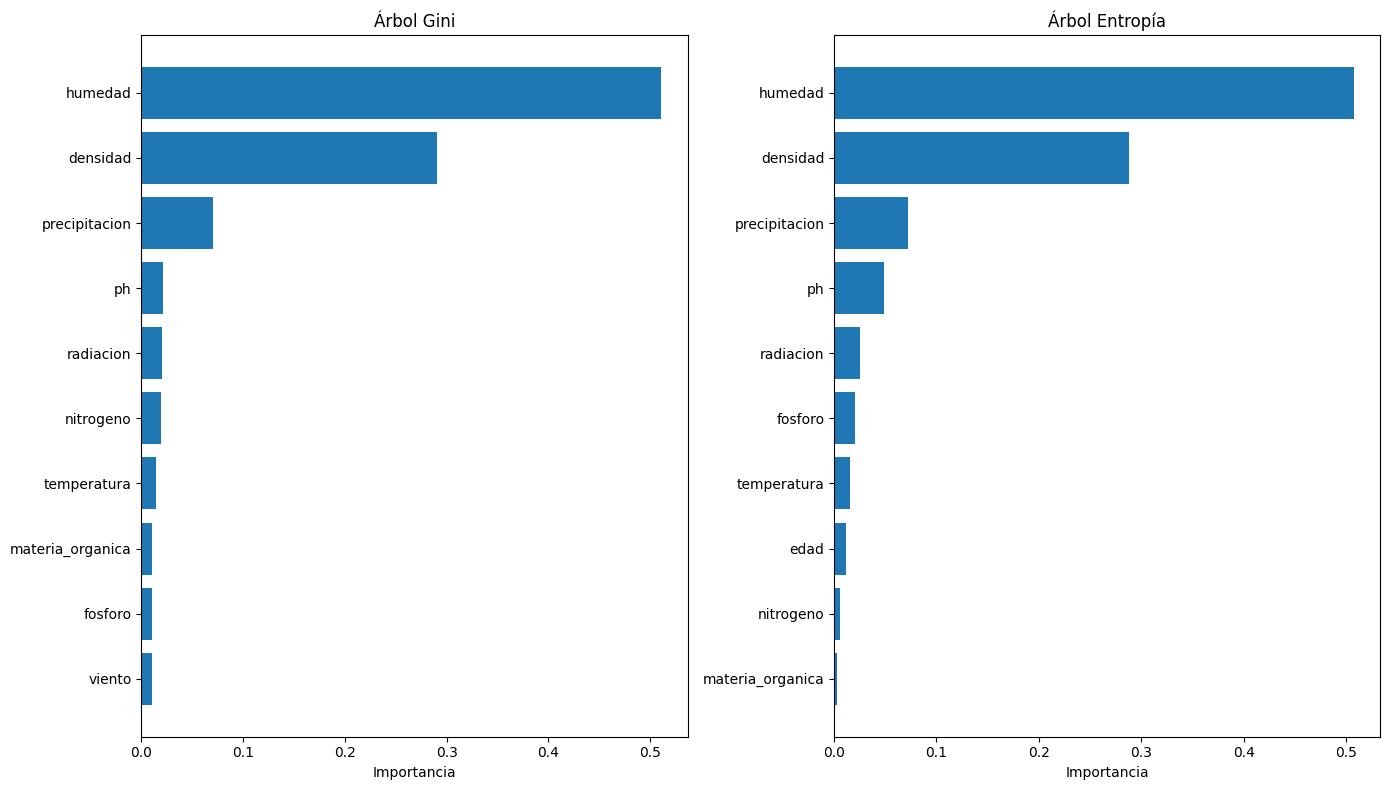

,Variable,Importancia,Modelo
0,humedad,0.511070,Árbol Gini
1,densidad,0.290385,Árbol Gini
2,precipitacion,0.070464,Árbol Gini
3,ph,0.021220,Árbol Gini
4,radiacion,0.020209,Árbol Gini
5,nitrogeno,0.018750,Árbol Gini
6,temperatura,0.014268,Árbol Gini
7,materia_organica,0.010339,Árbol Gini
8,fosforo,0.010133,Árbol Gini
9,viento,0.009910,Árbol Gini


In [74]:
variables = f_variables_importantes(
    modelos=[modelo_AC_gini, modelo_AC_entropia],

    nombres_modelos=["Árbol Gini", "Árbol Entropía"])

variables

### Matriz de confusión de árbol con Gini

Con la función *f_matriz_confusion()* se extrae la matriz de confusión y los estadísticos de ambos modelos. Los resultados advierten que la técnica de entropía como medida de impureza ofrece mejor calidad predictiva con dos modelos y con estos datos.


In [75]:
matriz_gini = f_matriz_confusion(
    modelo=modelo_AC_gini,
    datos_validacion=datos_validacion,
    variable_dependiente="salud"
)

matriz_gini["matriz_confusion"]


,Pred_Enfermedad,Pred_Estres_Hidrico,Pred_Plaga,Pred_Sano
Real_Enfermedad,65,0,7,0
Real_Estres_Hidrico,0,66,7,0
Real_Plaga,9,9,52,5
Real_Sano,0,1,2,77


In [76]:
matriz_gini["estadisticos"]

,Accuracy,Kappa,Precision,Recall,F1,Balanced_Accuracy
0,0.8667,0.8221,0.8637,0.8667,0.8646,0.8657


### Matriz de confusión de árbol con entropia

In [77]:
matriz_entropia = f_matriz_confusion(
    modelo=modelo_AC_entropia,
    datos_validacion=datos_validacion,
    variable_dependiente="salud"
)
matriz_entropia["matriz_confusion"]


,Pred_Enfermedad,Pred_Estres_Hidrico,Pred_Plaga,Pred_Sano
Real_Enfermedad,67,0,4,1
Real_Estres_Hidrico,0,66,7,0
Real_Plaga,1,5,67,2
Real_Sano,2,0,3,75


In [78]:
matriz_entropia["estadisticos"]

,Accuracy,Kappa,Precision,Recall,F1,Balanced_Accuracy
0,0.9167,0.8888,0.9191,0.9167,0.9174,0.9164


## Modelo bosques aleatorios

Se crea el modelo de bosques aleatorios con los mismos datos de entrenamiento con la finalidad de comparar calidad predictiva con los modelos anteriores.

### Medida Gini




In [79]:
modelo_RF_gini = f_construir_random_forest(
    datos_entrenamiento,
    "salud",
    criterion="gini"
)





 RANDOM FOREST
Variable objetivo : salud
Número de clases  : 4
Variables         : 15
Árboles           : 500
Criterio          : gini
Observaciones     : 700

Frecuencias:
Enfermedad: 178
Estres_Hidrico: 177
Plaga: 175
Sano: 170


### Medida entropía

In [80]:
modelo_RF_entropia = f_construir_random_forest(
    datos_entrenamiento,
    "salud",
    criterion="entropy"
)


 RANDOM FOREST
Variable objetivo : salud
Número de clases  : 4
Variables         : 15
Árboles           : 500
Criterio          : entropy
Observaciones     : 700

Frecuencias:
Enfermedad: 178
Estres_Hidrico: 177
Plaga: 175
Sano: 170


## Modelo de regresión logística

### Estandarizar variables independientes

El conjunto de datos tiene todas las variable independientes numéricas, para construir mnodelos como el de regresión logística, es sugerible estandaraziar los datos.

En procesos formales de aprendizaje automático, una buena práctica aplicar un proceso de estandarización utilizando únicamente la información contenida en el conjunto de entrenamiento. Los parámetros obtenidos (media y desviación estándar) son utilizados para transformar el conjunto de validación. Este procedimiento evita la fuga de información o *data leakage* y garantiza una evaluación más objetiva de la capacidad predictiva del modelo (James et al., 2021; Hastie et al., 2009).


La función *f_estandarizar_train_transf_valid()*, recibe los datos ya particionados, calcula medias y desviaciones únicamente con entrenamiento, estandariza entrenamiento,
aplica exactamente la misma transformación a los datos de validación y devuelve ambos conjuntos listos para construir y evaluar el modelo.

Se crea el modelo de regresión logística de tipo multinomial  con los datos de entrenamiento estandarizados. Se ejecuta la función *f_crear_modelo_regresion_logistica()*


In [81]:
resultado = f_estandarizar_train_transf_valid(
    datos_entrenamiento, datos_validacion, "salud")

datos_entrenamiento_std = (resultado["datos_entrenamiento"])

datos_validacion_std = (resultado["datos_validacion"])


In [82]:
modelo_RLM = f_crear_modelo_regresion_logistica(
    datos_entrenamiento_std,
    "salud",
    tipo="multinomial")



 REGRESIÓN LOGÍSTICA 
Tipo               : multinomial
Balanceo           : ninguno
Variable objetivo  : salud
Número de clases   : 4

Frecuencias originales:
{'Enfermedad': 178, 'Estres_Hidrico': 177, 'Plaga': 175, 'Sano': 170}

Frecuencias entrenamiento:
{'Enfermedad': 178, 'Estres_Hidrico': 177, 'Plaga': 175, 'Sano': 170}

Observaciones usadas: 700


In [83]:
f_matriz_confusion(
    modelo=modelo_RLM,
    datos_validacion=datos_validacion_std,
    variable_dependiente="salud"
)

{'matriz_confusion':                      Pred_Enfermedad  Pred_Estres_Hidrico  Pred_Plaga  \
 Real_Enfermedad                   71                    0           1   
 Real_Estres_Hidrico                0                   70           3   
 Real_Plaga                         1                    4          70   
 Real_Sano                          0                    0           1   
 
                      Pred_Sano  
 Real_Enfermedad              0  
 Real_Estres_Hidrico          0  
 Real_Plaga                   0  
 Real_Sano                   79  ,
 'estadisticos':    Accuracy   Kappa  Precision  Recall      F1  Balanced_Accuracy
 0    0.9667  0.9555     0.9668  0.9667  0.9667             0.9665}

## Evaluar modelos

Con los modelos creados, se hace la evaluación de modelos usando la función *f_evaluación()* con los argumentos de cada modelo.

Los resultados en modo consola indican el mejor modelo predicitov es el de bosques aleatorios seguido del modelo de regresión logística para estos datos.

In [84]:
evaluacion = f_evaluacion(
    modelos=[modelo_AC_gini, modelo_AC_entropia,
             modelo_RF_gini, modelo_RF_entropia, modelo_RLM],
    datos_validacion=[datos_validacion, datos_validacion,
        datos_validacion, datos_validacion,
        datos_validacion_std],
    variable_dependiente = "salud",
    clase_interes=None,
    nombres_modelos=["Arboles Gini", "Arboles entropía",
        "Bosques aleatorios Gini", "Bosques aleatorios entropía",
        "Regresión Logística"]
)

evaluacion

,Modelo,Accuracy,Kappa,Precision,Recall,F1,Balanced_Accuracy,Balanceo
0,Arboles Gini,0.8667,0.8221,0.8637,0.8667,0.8646,0.8657,NaN
1,Arboles entropía,0.9167,0.8888,0.9191,0.9167,0.9174,0.9164,NaN
2,Bosques aleatorios Gini,0.9600,0.9466,0.9600,0.9600,0.9600,0.9598,NaN
3,Bosques aleatorios entropía,0.9600,0.9466,0.9602,0.9600,0.9601,0.9597,NaN
4,Regresión Logística,0.9667,0.9555,0.9668,0.9667,0.9667,0.9665,ninguno


# Interpretación del caso de estudio

El caso de estudio cumple con el objetivo planteado de inicio, el de cosntruir, comparar y evaluar modelos de clasificación.

Se hicieron particiones a los datos *70%* para datos de entrenamiento y 30% para datos de validación. Con estas particiones, se construyeron los modelos árboles de clasificación y bosques aleatorios, en ambos modelos con criterios de impurezas *Gini* y entropía.

Luego, a partir de las particiones existentes, se estandrazaron los datos de entrenamiento y transformaron los datos de validación; esto ayudó a construir el modelo de regresión logística mas eficiente.

En cuanto a calidad predictiva para estos datos se tuvieron estos resultados:

El árbol de clasificación construido mediante entropía alcanzó una exactitud superior al árbol construido con el Índice de *Gini*, lo que sugiere que este criterio de impureza identificó particiones más informativas para los datos analizados.

Por otra parte, los modelos de bosques aleatorios construidos con *Gini* entropía alcanzaron resultados prácticamente idénticos, con una exactitud cercana al 96%.

Finalmente, la regresión logística multinomial presentó el mejor desempeño predictivo, alcanzando una exactitud de *96.67%*, un coeficiente *Kappa* de *0.9555* y un *F1-Score* de *0.9667*.

Este resultado sugiere que las clases de la variable dependiente presentan una estructura tal vez con comportamiento lineal, permitiendo que un modelo paramétrico como el de regresión logística tenga un desempeño ligeramente superior al de los modelos basados en árboles.

Estos resultados de la evaluación en términos de calidad predictiva fueron el resultado de la comparación de estos modelos de clasificación para estos datos.
